# Stored restriction maps visualisations

## 1. Imports

In [2]:
import torch

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import networkx as nx

#Cornell
maps = torch.load("/Users/luigifracassetti/projects/neural-sheaf-diffusion/results/maps/DiagSheaf_wisconsin_fold0_seed43_20260317_143017.pt")

print(type(maps))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/luigifracassetti/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/luigifracassetti/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/luigifracassetti/projects/neural-sheaf-diffusion/.venv/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/luigifracassetti/projects/neural-sheaf-diffusion/.venv/lib/python3.9

<class 'torch.Tensor'>


## 2. Inspection

In [3]:
print(type(maps))
print(len(maps) if hasattr(maps, '__len__') else "Not iterable")

# If it's a tensor
if isinstance(maps, torch.Tensor):
    print(maps.shape)

# If it's a list or dict
if isinstance(maps, (list, tuple)):
    print(type(maps[0]), maps[0].shape)

if isinstance(maps, dict):
    print(maps.keys())

print(maps[:10])

<class 'torch.Tensor'>
900
torch.Size([900, 3])
tensor([[  0.0000,   7.0000,  -0.4420],
        [  0.0000,  20.0000,  -0.4897],
        [  0.0000,  28.0000,  -0.4285],
        [  0.0000,  99.0000,  -0.6345],
        [  0.0000, 104.0000,  -0.5030],
        [  0.0000, 200.0000,  -0.5630],
        [  1.0000,  98.0000,  -0.5289],
        [  2.0000,  54.0000,  -0.3326],
        [  2.0000,  98.0000,  -0.5027],
        [  3.0000,  52.0000,  -0.5865]])


## 3. Boundary Map

In [4]:
print(maps)

tensor([[  0.0000,   7.0000,  -0.4420],
        [  0.0000,  20.0000,  -0.4897],
        [  0.0000,  28.0000,  -0.4285],
        ...,
        [242.0000, 215.0000,  -0.5266],
        [242.0000, 233.0000,  -0.5114],
        [249.0000, 242.0000,  -0.3321]])


In [5]:
df = pd.DataFrame(maps.cpu().tolist(),columns=["source", "target", "map_value"])

df[["source", "target"]] = df[["source", "target"]].astype(int)
df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
df

,source,target,map_value
0,0,7,-0.442021
1,0,20,-0.489709
2,0,28,-0.428454
3,0,99,-0.634534
4,0,104,-0.503031
...,...,...,...
888,247,200,0.169774
821,248,132,-0.471871
802,249,117,-0.498504
899,249,242,-0.332127


In [6]:
df_low = df[df["source"] <= df["target"]]
display(df_low)

df_high = df[df["source"] >= df["target"]]
display(df_high)

,source,target,map_value
0,0,7,-0.442021
1,0,20,-0.489709
2,0,28,-0.428454
3,0,99,-0.634534
4,0,104,-0.503031
...,...,...,...
445,209,232,-0.462757
446,210,225,-0.474908
447,215,242,-0.385633
448,233,242,-0.488782


,source,target,map_value
450,7,0,-0.424064
451,20,0,-0.512496
511,22,21,-0.495577
452,28,0,-0.371393
464,32,5,-0.014866
...,...,...,...
888,247,200,0.169774
821,248,132,-0.471871
802,249,117,-0.498504
899,249,242,-0.332127


In [7]:
df = df.copy()
df[["source", "target"]] = df[["source", "target"]].astype(int)

# signed value
df["signed_map"] = np.where(
    df["target"] < df["source"],
    df["map_value"],
    -df["map_value"]
)

# canonical undirected edge label
df["edge"] = df.apply(
    lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),
    axis=1
)

# build node-by-edge matrix
nodes = sorted(set(df["source"]).union(df["target"]))
edges = sorted(df["edge"].unique())

B = df.pivot(index="source", columns="edge", values="signed_map")
B = B.reindex(index=nodes, columns=edges, fill_value=0)

B.fillna(0, inplace=True)

In [8]:
B

edge,"(0.0, 7.0)","(0.0, 20.0)","(0.0, 28.0)","(0.0, 99.0)","(0.0, 104.0)","(0.0, 200.0)","(1.0, 98.0)","(2.0, 54.0)","(2.0, 98.0)","(3.0, 52.0)",...,"(201.0, 207.0)","(202.0, 223.0)","(202.0, 242.0)","(205.0, 242.0)","(207.0, 208.0)","(209.0, 232.0)","(210.0, 225.0)","(215.0, 242.0)","(233.0, 242.0)","(242.0, 249.0)"
source,,,,,,,,,,,,,,,,,,,,,
0,0.442021,0.489709,0.428454,0.634534,0.503031,0.563039,0.0000,0.000000,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.5289,0.000000,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.332626,0.502654,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.58647,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
247,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
248,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [9]:
((B != 0).sum(axis=0)).value_counts()

2    450
Name: count, dtype: int64

In [10]:
B_np = B.to_numpy(dtype=float)
B_np.shape

(251, 450)

## 4. Laplacian

In [11]:
L0 = B_np @ B_np.T
L0

array([[1.59145618, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.27973486, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.36330059, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.22266231, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.35881395,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.35435593]])

In [12]:
L1 = B_np.T @ B_np
np.all(L1 == L1.T)

np.True_

In [13]:
#Curvature
# F, w/ F[i,j] = L1

In [14]:
# Forman Bochner Decomposition
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])
#B=B.astype(int)
    F=L-B
    return B , F

B1, F1 = fbc(L1)
B1

array([[ 1.35192463,  0.2164616 ,  0.18938534, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.2164616 ,  2.93137125,  0.20981762, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.18938534,  0.20981762,  1.40805709, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  3.73431074,
         0.26928403, -0.19304634],
       [ 0.        ,  0.        ,  0.        , ...,  0.26928403,
         3.61865321, -0.18748889],
       [ 0.        ,  0.        ,  0.        , ..., -0.19304634,
        -0.18748889,  2.67815899]])

In [15]:
F1

array([[-0.97671179,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -2.42890453,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -1.08655201, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -3.30833156,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -3.11821398,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , -2.43344247]])

In [16]:
edge_list = list(B.columns)
print(edge_list)

[(np.float64(0.0), np.float64(7.0)), (np.float64(0.0), np.float64(20.0)), (np.float64(0.0), np.float64(28.0)), (np.float64(0.0), np.float64(99.0)), (np.float64(0.0), np.float64(104.0)), (np.float64(0.0), np.float64(200.0)), (np.float64(1.0), np.float64(98.0)), (np.float64(2.0), np.float64(54.0)), (np.float64(2.0), np.float64(98.0)), (np.float64(3.0), np.float64(52.0)), (np.float64(3.0), np.float64(66.0)), (np.float64(3.0), np.float64(204.0)), (np.float64(4.0), np.float64(98.0)), (np.float64(4.0), np.float64(195.0)), (np.float64(5.0), np.float64(32.0)), (np.float64(5.0), np.float64(45.0)), (np.float64(5.0), np.float64(81.0)), (np.float64(5.0), np.float64(101.0)), (np.float64(5.0), np.float64(141.0)), (np.float64(5.0), np.float64(168.0)), (np.float64(5.0), np.float64(204.0)), (np.float64(5.0), np.float64(211.0)), (np.float64(5.0), np.float64(236.0)), (np.float64(5.0), np.float64(246.0)), (np.float64(6.0), np.float64(98.0)), (np.float64(6.0), np.float64(170.0)), (np.float64(6.0), np.float

In [17]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)
f1 = np.diag(F1)
display(f1)

array([-9.76711785e-01, -2.42890453e+00, -1.08655201e+00, -1.15244666e+00,
       -1.48107618e+00, -1.08569309e+00, -2.41379679e+01, -1.51307067e+00,
       -3.38737992e+01, -1.56955746e+00, -3.59236522e-01, -2.32485555e+00,
       -1.85234517e+01,  4.95209230e-03, -1.83937856e+00, -2.22707004e+00,
       -2.34123385e+00, -2.16251792e+00, -1.86366280e+00, -2.49994236e+00,
       -3.43264194e+00, -3.13979946e+00, -2.15207497e+00, -2.74048840e+00,
       -1.82484420e+01, -1.42152245e+00, -2.23419491e+00, -2.16215748e+00,
       -1.70725778e+01, -8.52267020e-01, -3.93848373e-01, -1.70428209e+00,
       -2.74585278e+01, -2.33155253e-01, -1.68543096e-01, -7.36846118e-01,
       -2.99987405e+01, -2.76577457e-01, -4.65161115e-01, -4.30226582e-01,
       -2.77172086e+01, -5.15505954e-01, -6.26066631e-01, -1.27111513e+00,
       -6.15071208e+00, -3.06388445e-01, -1.79542856e+01, -2.57268344e+00,
       -3.81570904e-01, -2.25047661e+01, -1.96554372e+01, -7.41810092e+00,
       -5.11762329e-02, -

/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_61712/3886179207.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


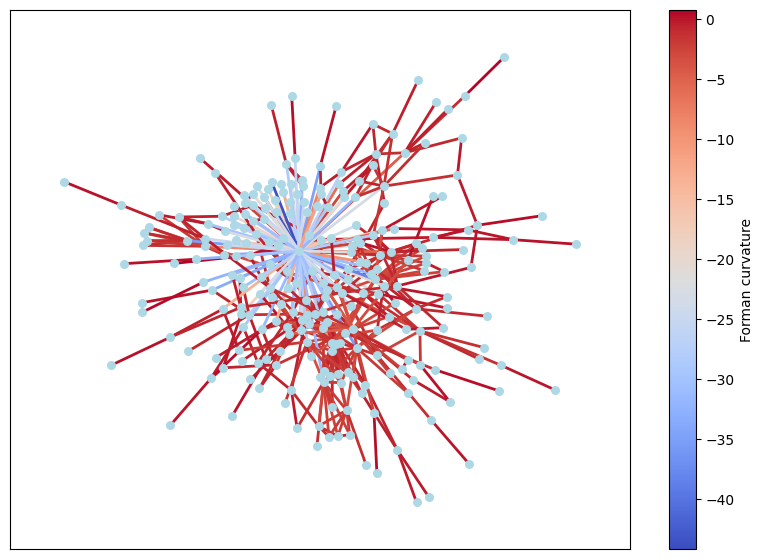

In [18]:
pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1(f1)),pos = pos, width=2)
sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
plt.colorbar(sm1, ax=ax, label='Forman curvature')
f.show()

In [19]:
B0, F0 = fbc(L0)

In [20]:
display(L0)

array([[1.59145618, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.27973486, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.36330059, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.22266231, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.35881395,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.35435593]])

In [21]:
display(F0)
display(B0)

array([[ 0.2526439 ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.0320332 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -0.08524661, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.07312448,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.02044545,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.10500132]])

array([[1.33881228, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.24770166, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.4485472 , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.29578679, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.37925941,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.24935461]])

In [22]:
G= nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)

array([ 2.52643895e-01,  3.20331998e-02, -8.52466127e-02,  3.06810662e-01,
        1.75086589e-01,  7.69135940e-01,  9.32187852e-03,  5.02071939e-02,
        2.04794603e-01, -4.56713480e-02, -1.69817910e-02,  3.63596426e-02,
       -3.50785910e-02,  2.43656219e-01, -1.30061604e-02,  4.19019928e-01,
        4.94616352e-01,  8.93956874e-02,  2.23966010e-01,  1.31703681e-01,
        1.27908839e-01,  1.06916180e-02,  2.08681547e-01,  2.38486333e-02,
        4.43546248e-01,  2.51134989e-01,  1.72311813e-02,  1.35101901e-01,
        1.63319230e-01, -5.40869091e-02,  1.05329789e-01, -2.34757060e-02,
       -2.54669842e-02,  1.95244508e-02,  3.90352503e-01,  7.85182305e-02,
        8.54984809e-02, -1.23131988e-01, -8.49477913e-02, -6.01572682e-02,
       -1.85369022e-02,  3.00669573e-01, -3.45136899e-02, -5.86417562e-02,
        4.41883876e-01, -1.89613456e-01, -9.25774092e-02,  7.91193678e-02,
       -7.97229523e-02, -2.50589558e-02,  5.15699479e-01,  4.80775338e-01,
        6.67739955e-01,  

/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_61712/4281192542.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


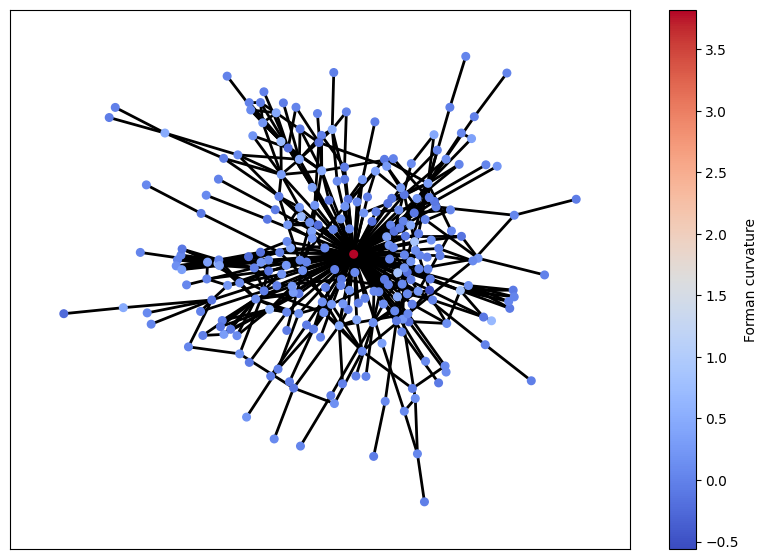

In [23]:

# G.relabel_nodes({i: node for i, node in enumerate(nodes)}, copy=False)
f0 = np.diag(F0)
display(f0)

pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm0 = plt.Normalize(vmin=f0.min(), vmax=f0.max())
nx.draw_networkx_nodes(G, ax=ax, node_color=cmap(norm0(f0)), pos = pos, node_size=30)
nx.draw_networkx_edges(G,ax =ax,pos = pos, width=2)
sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
plt.colorbar(sm0, ax=ax, label='Forman curvature')
f.show()

In [24]:
G.nodes()

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 

node_id	feature	label
0	0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_61712/168224487.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


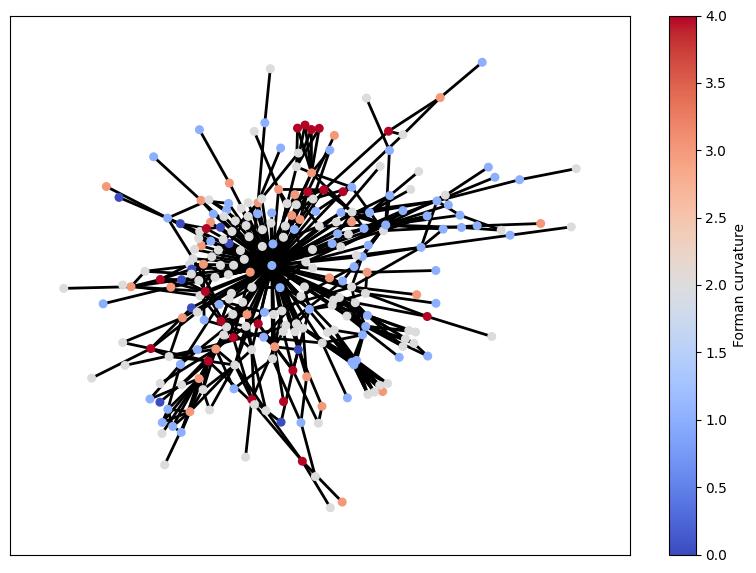

In [25]:
with open("/Users/luigifracassetti/projects/neural-sheaf-diffusion/datasets/wisconsin/raw/out1_node_feature_label.txt", "r") as f:
    for line in f:
        print(line.strip())
    df_node_feature = pd.read_csv("/Users/luigifracassetti/projects/neural-sheaf-diffusion/datasets/wisconsin/raw/out1_node_feature_label.txt", sep="\t")

lab = df_node_feature["label"].values
lab

pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm0 = plt.Normalize(vmin=lab.min(), vmax=lab.max())
nx.draw_networkx_nodes(G, ax=ax, node_color=cmap(norm0(lab)), pos = pos, node_size=30)
nx.draw_networkx_edges(G,ax =ax,pos = pos, width=2)
sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
plt.colorbar(sm0, ax=ax, label='Forman curvature')
f.show()

array([1, 2, 2, 2, 1, 1, 1, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 1, 1,
       2, 2, 1, 3, 1, 3, 1, 2, 2, 2, 2, 2, 1, 1, 1, 3, 1, 3, 2, 2, 1, 2,
       4, 2, 4, 3, 1, 2, 4, 4, 1, 1, 3, 2, 2, 2, 3, 1, 1, 2, 2, 4, 4, 2,
       1, 0, 2, 2, 2, 2, 2, 2, 1, 3, 2, 2, 1, 4, 2, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 4, 3, 2, 2, 2, 1, 1, 2, 0, 3, 3, 2, 2, 2, 2, 3, 1, 2,
       1, 2, 1, 1, 2, 1, 1, 2, 3, 4, 2, 3, 2, 2, 2, 2, 3, 1, 1, 2, 1, 0,
       2, 2, 2, 0, 2, 3, 0, 2, 2, 2, 2, 0, 3, 2, 3, 4, 1, 1, 1, 0, 1, 2,
       2, 2, 4, 4, 1, 4, 3, 4, 2, 2, 2, 4, 2, 1, 2, 2, 2, 2, 2, 3, 2, 3,
       3, 2, 3, 3, 2, 1, 2, 0, 4, 2, 4, 0, 1, 1, 2, 1, 3, 2, 2, 2, 1, 3,
       4, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 3, 2, 4, 2, 1, 1, 2, 1, 3, 3,
       2, 2, 1, 3, 1, 2, 2, 2, 1, 2, 2, 4, 2, 1, 2, 2, 2, 2, 2, 2, 3, 2,
       1, 1, 4, 1, 2, 2, 2, 1, 2])

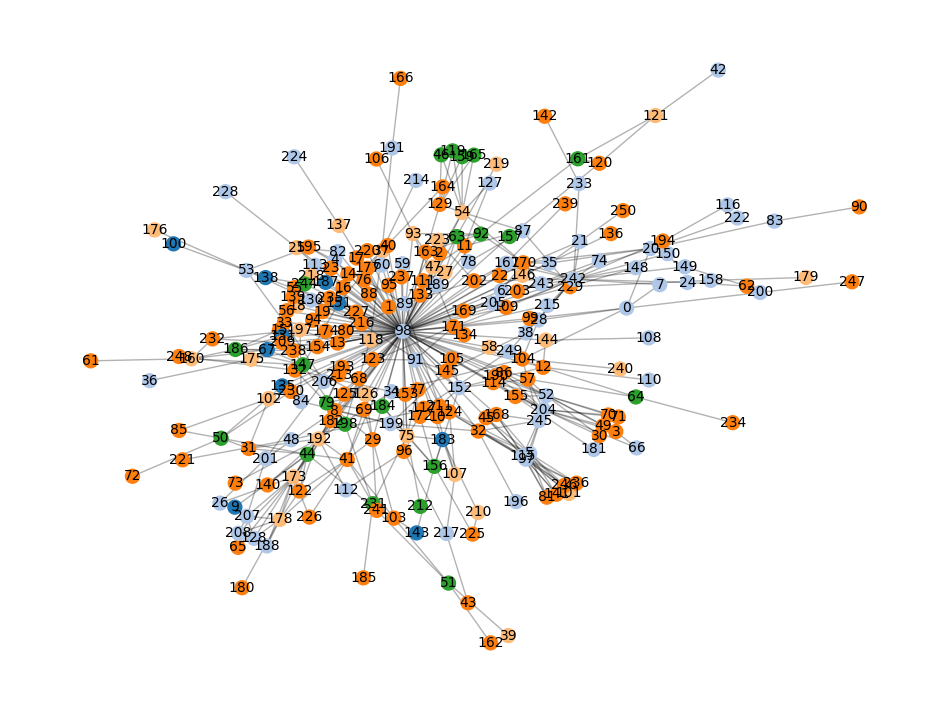

In [27]:
lab = df_node_feature["label"].values
display(lab)

# Plot graph nodes colored by `lab` (handles one-hot or integer labels). Uses existing `G` and `pos` if present.
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

labels = lab
if isinstance(labels, np.ndarray) and labels.ndim == 2:
    labels = labels.argmax(axis=1)

unique = np.unique(labels)

cmap = plt.get_cmap('tab20')
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap(label_to_idx[int(labels[n]) % 20]) for n in sorted(G.nodes())]

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)

plt.figure(figsize=(12, 9))
nx.draw_networkx_nodes(G, pos_use, node_color=node_colors, node_size=100)
nx.draw_networkx_edges(G, pos_use, alpha=0.3)
nx.draw_networkx_labels(G, pos=pos_use, font_size=10)
plt.axis('off')
plt.show()

In [ ]:
neigh_98_edges =[_ for _  in list(G.edges()) if 98 in _]
# display(neigh_98_edges)

neigh_98_nodes = [int(j) if i == 98 else int(i) for (i, j) in neigh_98_edges]
# display(neigh_98_nodes)

#associating neighborhing nodes to their labels
neigh_98_labels = {n: int(lab[n]) for n in neigh_98_nodes}
# display(neigh_98_labels)

similar_class_ratio = sum(1 for n in neigh_98_nodes if lab[n] == lab[98]) / len(neigh_98_nodes)
similar_class_ratio

[(1, np.float64(98.0)),
 (2, np.float64(98.0)),
 (4, np.float64(98.0)),
 (6, np.float64(98.0)),
 (8, np.float64(98.0)),
 (10, np.float64(98.0)),
 (11, np.float64(98.0)),
 (12, np.float64(98.0)),
 (13, np.float64(98.0)),
 (14, np.float64(98.0)),
 (15, np.float64(98.0)),
 (16, np.float64(98.0)),
 (17, np.float64(98.0)),
 (18, np.float64(98.0)),
 (19, np.float64(98.0)),
 (22, np.float64(98.0)),
 (23, np.float64(98.0)),
 (25, np.float64(98.0)),
 (27, np.float64(98.0)),
 (28, np.float64(98.0)),
 (29, np.float64(98.0)),
 (32, np.float64(98.0)),
 (33, np.float64(98.0)),
 (35, np.float64(98.0)),
 (37, np.float64(98.0)),
 (40, np.float64(98.0)),
 (41, np.float64(98.0)),
 (44, np.float64(98.0)),
 (45, np.float64(98.0)),
 (47, np.float64(98.0)),
 (52, np.float64(98.0)),
 (54, np.float64(98.0)),
 (55, np.float64(98.0)),
 (56, np.float64(98.0)),
 (57, np.float64(98.0)),
 (58, np.float64(98.0)),
 (59, np.float64(98.0)),
 (60, np.float64(98.0)),
 (63, np.float64(98.0)),
 (67, np.float64(98.0)),
 (68,

[1,
 2,
 4,
 6,
 8,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 22,
 23,
 25,
 27,
 28,
 29,
 32,
 33,
 35,
 37,
 40,
 41,
 44,
 45,
 47,
 52,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 63,
 67,
 68,
 69,
 75,
 76,
 77,
 78,
 80,
 82,
 86,
 88,
 92,
 93,
 94,
 95,
 96,
 99,
 102,
 104,
 105,
 109,
 111,
 113,
 114,
 123,
 124,
 125,
 126,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 137,
 138,
 139,
 144,
 145,
 146,
 147,
 153,
 154,
 155,
 157,
 163,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 177,
 182,
 183,
 184,
 187,
 189,
 190,
 192,
 193,
 202,
 203,
 204,
 205,
 209,
 211,
 213,
 216,
 218,
 220,
 227,
 229,
 230,
 235,
 237,
 238,
 243,
 244]

{1: 2,
 2: 2,
 4: 1,
 6: 1,
 8: 2,
 10: 2,
 11: 2,
 12: 2,
 13: 2,
 14: 2,
 15: 2,
 16: 2,
 17: 2,
 18: 3,
 19: 2,
 22: 2,
 23: 2,
 25: 3,
 27: 3,
 28: 1,
 29: 2,
 32: 2,
 33: 2,
 35: 1,
 37: 3,
 40: 2,
 41: 2,
 44: 4,
 45: 2,
 47: 3,
 52: 1,
 54: 3,
 55: 2,
 56: 2,
 57: 2,
 58: 3,
 59: 1,
 60: 1,
 63: 4,
 67: 0,
 68: 2,
 69: 2,
 75: 3,
 76: 2,
 77: 2,
 78: 1,
 80: 2,
 82: 1,
 86: 2,
 88: 2,
 92: 4,
 93: 3,
 94: 2,
 95: 2,
 96: 2,
 99: 2,
 102: 3,
 104: 2,
 105: 2,
 109: 2,
 111: 2,
 113: 1,
 114: 2,
 123: 2,
 124: 2,
 125: 2,
 126: 3,
 129: 2,
 130: 1,
 131: 0,
 132: 2,
 133: 2,
 134: 2,
 135: 0,
 137: 3,
 138: 0,
 139: 2,
 144: 3,
 145: 2,
 146: 3,
 147: 4,
 153: 2,
 154: 2,
 155: 2,
 157: 4,
 163: 2,
 167: 1,
 168: 2,
 169: 2,
 170: 2,
 171: 2,
 172: 2,
 173: 3,
 174: 2,
 175: 3,
 177: 2,
 182: 2,
 183: 0,
 184: 4,
 187: 0,
 189: 1,
 190: 2,
 192: 3,
 193: 2,
 202: 2,
 203: 2,
 204: 1,
 205: 1,
 209: 2,
 211: 2,
 213: 2,
 216: 2,
 218: 3,
 220: 2,
 227: 2,
 229: 2,
 230: 2,
 235: 2,

0.13114754098360656

array([-9.76711785e-01, -2.42890453e+00, -1.08655201e+00, -1.15244666e+00,
       -1.48107618e+00, -1.08569309e+00, -2.41379679e+01, -1.51307067e+00,
       -3.38737992e+01, -1.56955746e+00, -3.59236522e-01, -2.32485555e+00,
       -1.85234517e+01,  4.95209230e-03, -1.83937856e+00, -2.22707004e+00,
       -2.34123385e+00, -2.16251792e+00, -1.86366280e+00, -2.49994236e+00,
       -3.43264194e+00, -3.13979946e+00, -2.15207497e+00, -2.74048840e+00,
       -1.82484420e+01, -1.42152245e+00, -2.23419491e+00, -2.16215748e+00,
       -1.70725778e+01, -8.52267020e-01, -3.93848373e-01, -1.70428209e+00,
       -2.74585278e+01, -2.33155253e-01, -1.68543096e-01, -7.36846118e-01,
       -2.99987405e+01, -2.76577457e-01, -4.65161115e-01, -4.30226582e-01,
       -2.77172086e+01, -5.15505954e-01, -6.26066631e-01, -1.27111513e+00,
       -6.15071208e+00, -3.06388445e-01, -1.79542856e+01, -2.57268344e+00,
       -3.81570904e-01, -2.25047661e+01, -1.96554372e+01, -7.41810092e+00,
       -5.11762329e-02, -

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

array([[1., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.]])

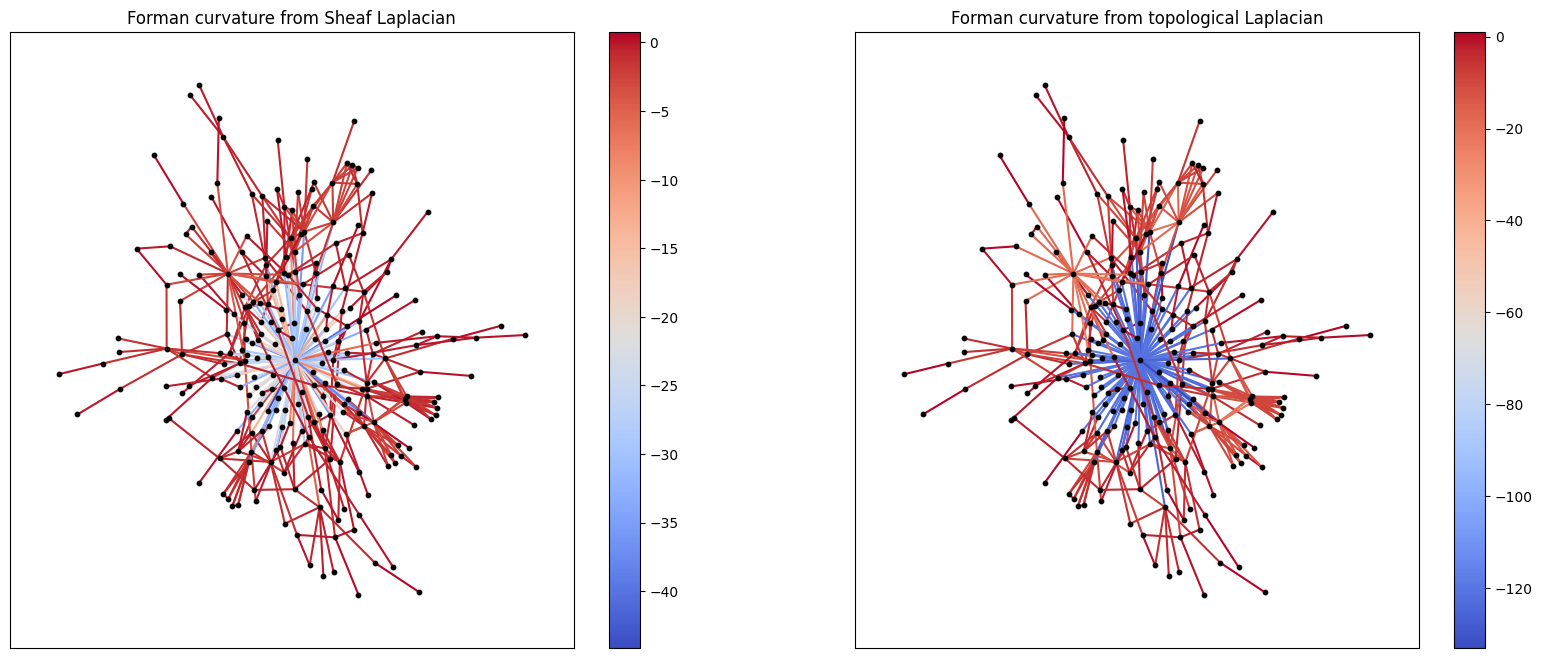

In [29]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)
f1 = np.diag(F1)
display(f1)

# pos = nx.spring_layout(G)
# f,ax = plt.subplots(1,1,figsize=(10,7))
# nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
# #nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
# cmap = plt.cm.coolwarm
# norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
# nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1(f1)),pos = pos, width=2)
# sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
# plt.colorbar(sm1, ax=ax, label='Forman curvature')

B_top = nx.incidence_matrix(G).todense()
L0_top = B_top @ B_top.T
L1_top = B_top.T @ B_top
B0_top, F0_top = fbc(L0_top)
B1_top, F1_top = fbc(L1_top)
f0_top = np.diag(F0_top)
f1_top = np.diag(F1_top)
display(f0_top)
display(B_top)

# pos = nx.spring_layout(G)
# f,ax = plt.subplots(1,1,figsize=(10,7))
# nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
# #nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
# cmap = plt.cm.coolwarm
# norm1_top = plt.Normalize(vmin=f1.min(), vmax=f1.max())
# nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1_top(f1_top)),pos = pos, width=2)
# sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1_top)
# plt.colorbar(sm1, ax=ax, label='Forman curvature topological ')
# f.show()

pos = nx.spring_layout(G)
f,ax = plt.subplots(1,2,figsize=(20,8))
cmap = plt.cm.coolwarm

nx.draw_networkx_nodes(G, ax=ax[0], node_color='k', pos = pos, node_size=10)
nx.draw_networkx_nodes(G, ax=ax[1], node_color='k', pos = pos, node_size=10)

norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
norm1_top = plt.Normalize(vmin=f1_top.min(), vmax=f1_top.max())

nx.draw_networkx_edges(G,ax =ax[0], edge_color = cmap(norm1(f1)),pos = pos, width=1.5)
nx.draw_networkx_edges(G,ax =ax[1], edge_color = cmap(norm1_top(f1_top)),pos = pos, width=1.5)

sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
plt.colorbar(sm1, ax=ax[0])
sm1_top = plt.cm.ScalarMappable(cmap=cmap, norm=norm1_top)
plt.colorbar(sm1_top, ax=ax[1])

ax[0].set_title("Forman curvature from Sheaf Laplacian")
ax[1].set_title("Forman curvature from topological Laplacian")
plt.show()

array([1, 2, 2, 2, 1, 1, 1, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 1, 1,
       2, 2, 1, 3, 1, 3, 1, 2, 2, 2, 2, 2, 1, 1, 1, 3, 1, 3, 2, 2, 1, 2,
       4, 2, 4, 3, 1, 2, 4, 4, 1, 1, 3, 2, 2, 2, 3, 1, 1, 2, 2, 4, 4, 2,
       1, 0, 2, 2, 2, 2, 2, 2, 1, 3, 2, 2, 1, 4, 2, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 4, 3, 2, 2, 2, 1, 1, 2, 0, 3, 3, 2, 2, 2, 2, 3, 1, 2,
       1, 2, 1, 1, 2, 1, 1, 2, 3, 4, 2, 3, 2, 2, 2, 2, 3, 1, 1, 2, 1, 0,
       2, 2, 2, 0, 2, 3, 0, 2, 2, 2, 2, 0, 3, 2, 3, 4, 1, 1, 1, 0, 1, 2,
       2, 2, 4, 4, 1, 4, 3, 4, 2, 2, 2, 4, 2, 1, 2, 2, 2, 2, 2, 3, 2, 3,
       3, 2, 3, 3, 2, 1, 2, 0, 4, 2, 4, 0, 1, 1, 2, 1, 3, 2, 2, 2, 1, 3,
       4, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 3, 2, 4, 2, 1, 1, 2, 1, 3, 3,
       2, 2, 1, 3, 1, 2, 2, 2, 1, 2, 2, 4, 2, 1, 2, 2, 2, 2, 2, 2, 3, 2,
       1, 1, 4, 1, 2, 2, 2, 1, 2])

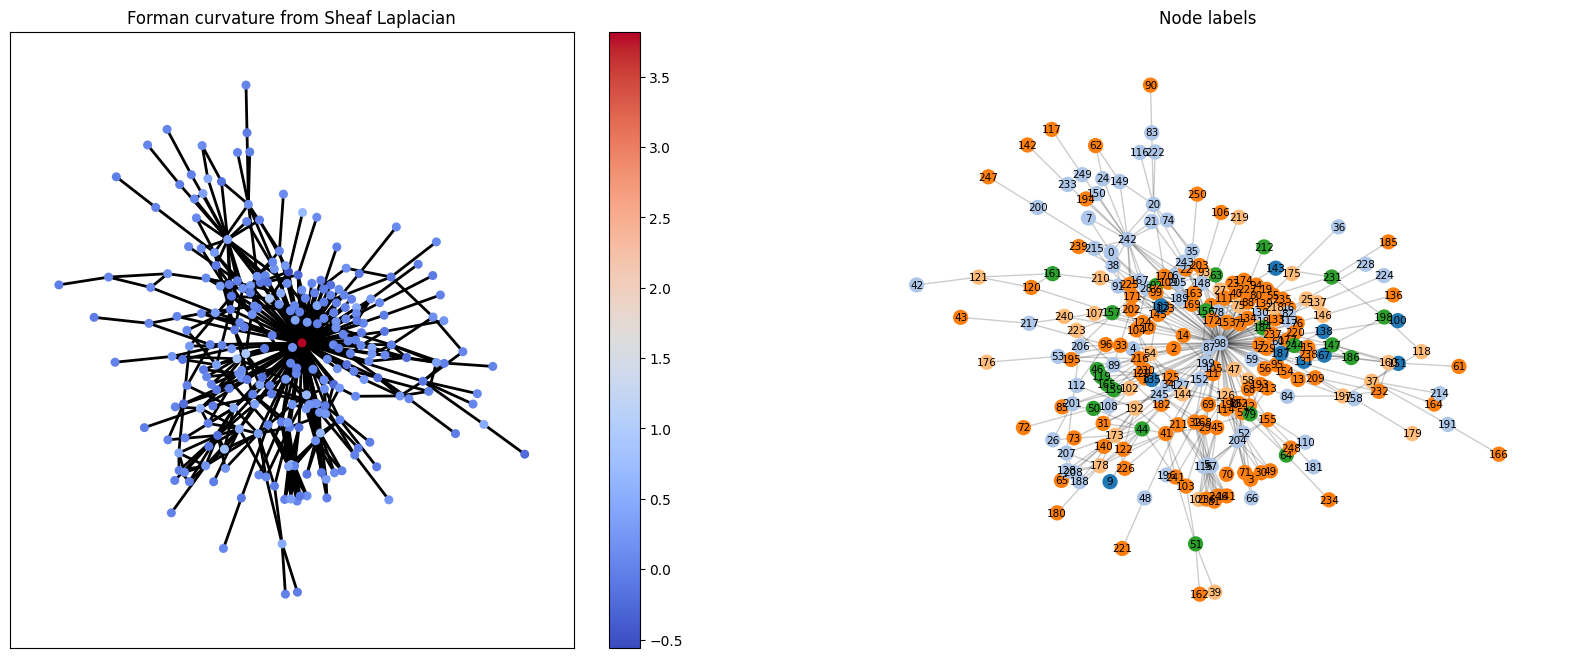

In [ ]:
pos = nx.spring_layout(G)
lab = df_node_feature["label"].values
# display(lab)

# Plot graph nodes colored by `lab` (handles one-hot or integer labels). Uses existing `G` and `pos` if present.
f,ax = plt.subplots(1,2,figsize=(20,8))
cmap = plt.cm.coolwarm

norm0 = plt.Normalize(vmin=f0.min(), vmax=f0.max())
nx.draw_networkx_nodes(G, ax=ax[0], node_color=cmap(norm0(f0)), pos = pos, node_size=30)
nx.draw_networkx_edges(G,ax =ax[0],pos = pos, width=2)
sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
ax[0].set_title("Forman curvature from Sheaf Laplacian")
plt.colorbar(sm0, ax=ax[0])

if isinstance(labels, np.ndarray) and labels.ndim == 2:
    labels = labels.argmax(axis=1)

labels = lab
unique = np.unique(labels)

cmap_classes = plt.get_cmap('tab20')
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap_classes(label_to_idx[int(labels[n]) % 20]) for n in sorted(G.nodes())]

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, ax=ax[1], node_color=node_colors, node_size=100, pos=pos_use)
nx.draw_networkx_edges(G, ax=ax[1], pos=pos_use, alpha=0.2)
nx.draw_networkx_labels(G, ax=ax[1], pos=pos_use, font_size=7.5)
ax[1].set_title("Node labels")
plt.axis('off')

plt.show()